# GPT CE Analysis — interactive plotting
Remake of the CE loss figure with DiT-matched colour convention.
- **Train**: blue `#2166ac`
- **Valid (novel)**: red `#d73027`
- **Boolean cube**: gray dashed `#555555`

In [57]:
%load_ext autoreload
%autoreload 2

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


In [58]:
import sys, os
sys.path.insert(0, os.path.abspath(".."))

import numpy as np
import matplotlib as mpl
import matplotlib.pyplot as plt
from matplotlib.colors import Normalize

%matplotlib inline
mpl.rcParams['pdf.fonttype'] = 42
mpl.rcParams['ps.fonttype']  = 42
mpl.rcParams['axes.spines.right'] = False
mpl.rcParams['axes.spines.top']   = False
plt.rcParams['figure.dpi'] = 150

In [59]:
# ── Import the plotting helpers from the script ──────────────────────────────
from scripts.plot_GPT_CE_analysis import (
    plot_ce_figure, load_ce_data,
    SPLIT_STYLES, HMAP_CMAP, HMAP_TITLE_COLORS, HMAP_TITLES,
    make_step_axis, heatmap_step_ticks, group_boundary_lines,
)
from scripts.plot_tb_curves import load_tb_scalars
from core.onset_lib import (
    first_sustained_crossing, get_onsets, collect_onsets,
    load_eval_timeseries,
)

In [60]:
# ── Import the plotting helpers from the script ──────────────────────────────
from scripts.plot_GPT_CE_analysis import (
    plot_ce_figure, load_ce_data,
    # SPLIT_STYLES, HMAP_CMAPS, HMAP_TITLES,
    make_step_axis, heatmap_step_ticks, group_boundary_lines,
)
from scripts.plot_tb_curves import load_tb_scalars
from circuit_toolkit.plot_utils import saveallforms

In [ ]:
SAVEROOT = (
    "/n/holylfs06/LABS/kempner_fellow_binxuwang/Users/binxuwang/"
    "DL_Projects/DiffusionParityLearning"
)
FIGDIR = (
    "/n/home12/binxuwang/Github/DiffusionAttnConsistency/figures/"
    "GPT_parity_learn_dissection"
)
os.makedirs(FIGDIR, exist_ok=True)

EXP_NAMES = [
    "GPT_mini_parity_N4096_D36_G6_even_lr1e4",
    "GPT_mini_parity_N4096_D36_G6_even_wd1e2",
]
GROUP_SIZE = 6
N_EVAL     = 4096

## Quick one-shot: generate both runs

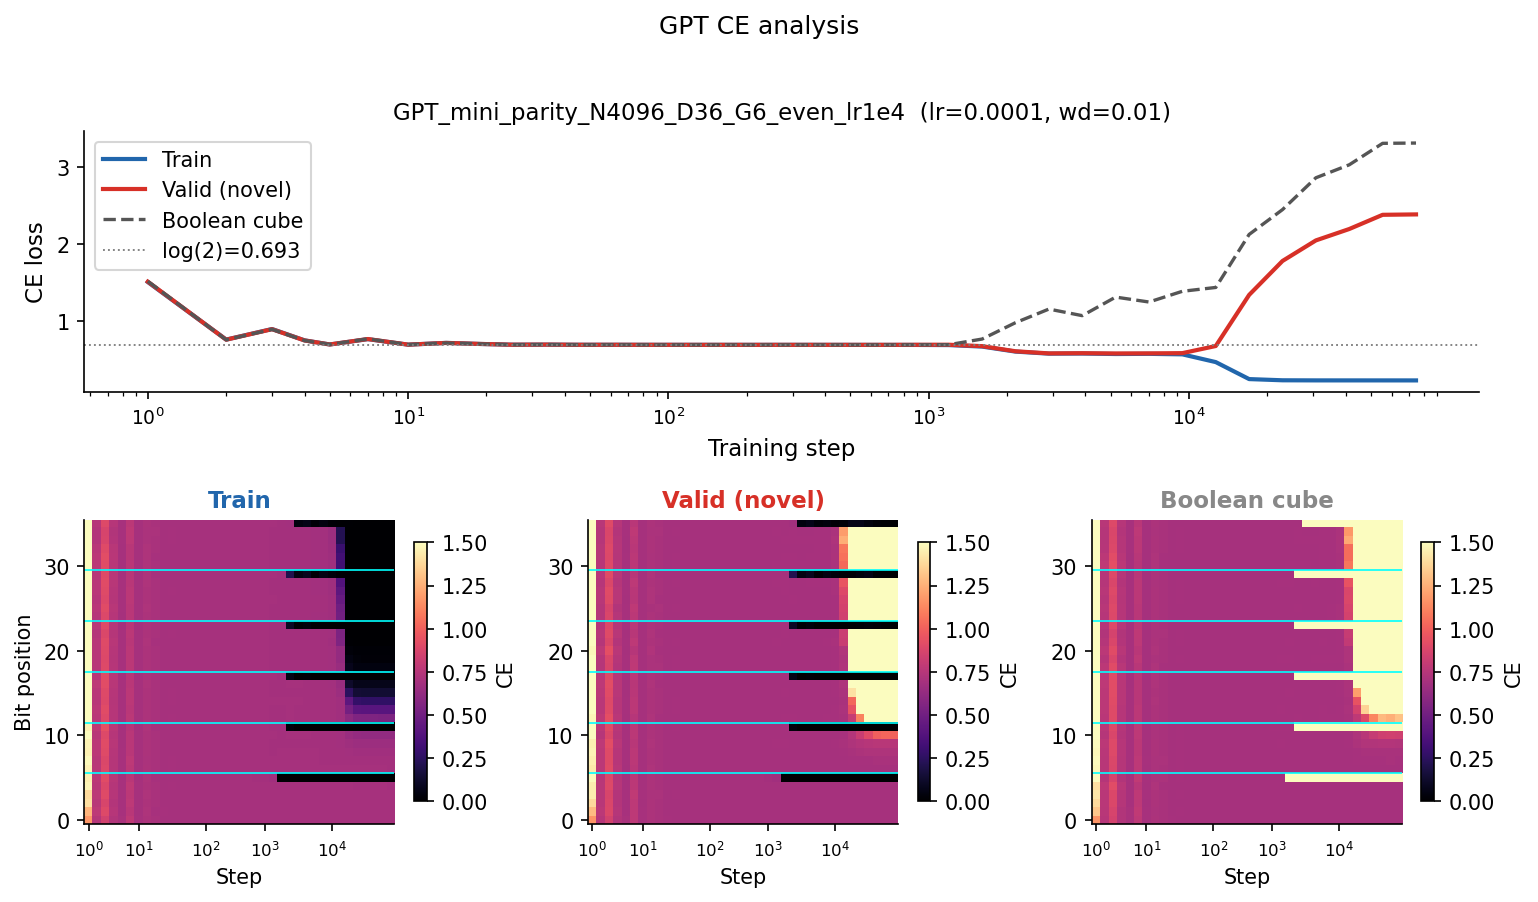

Saved → /n/home12/binxuwang/Github/DiffusionAttnConsistency/figures/GPT_parity_learn_dissection/GPT_G6_CE_analysis_G6_lr1e4.{pdf,png}


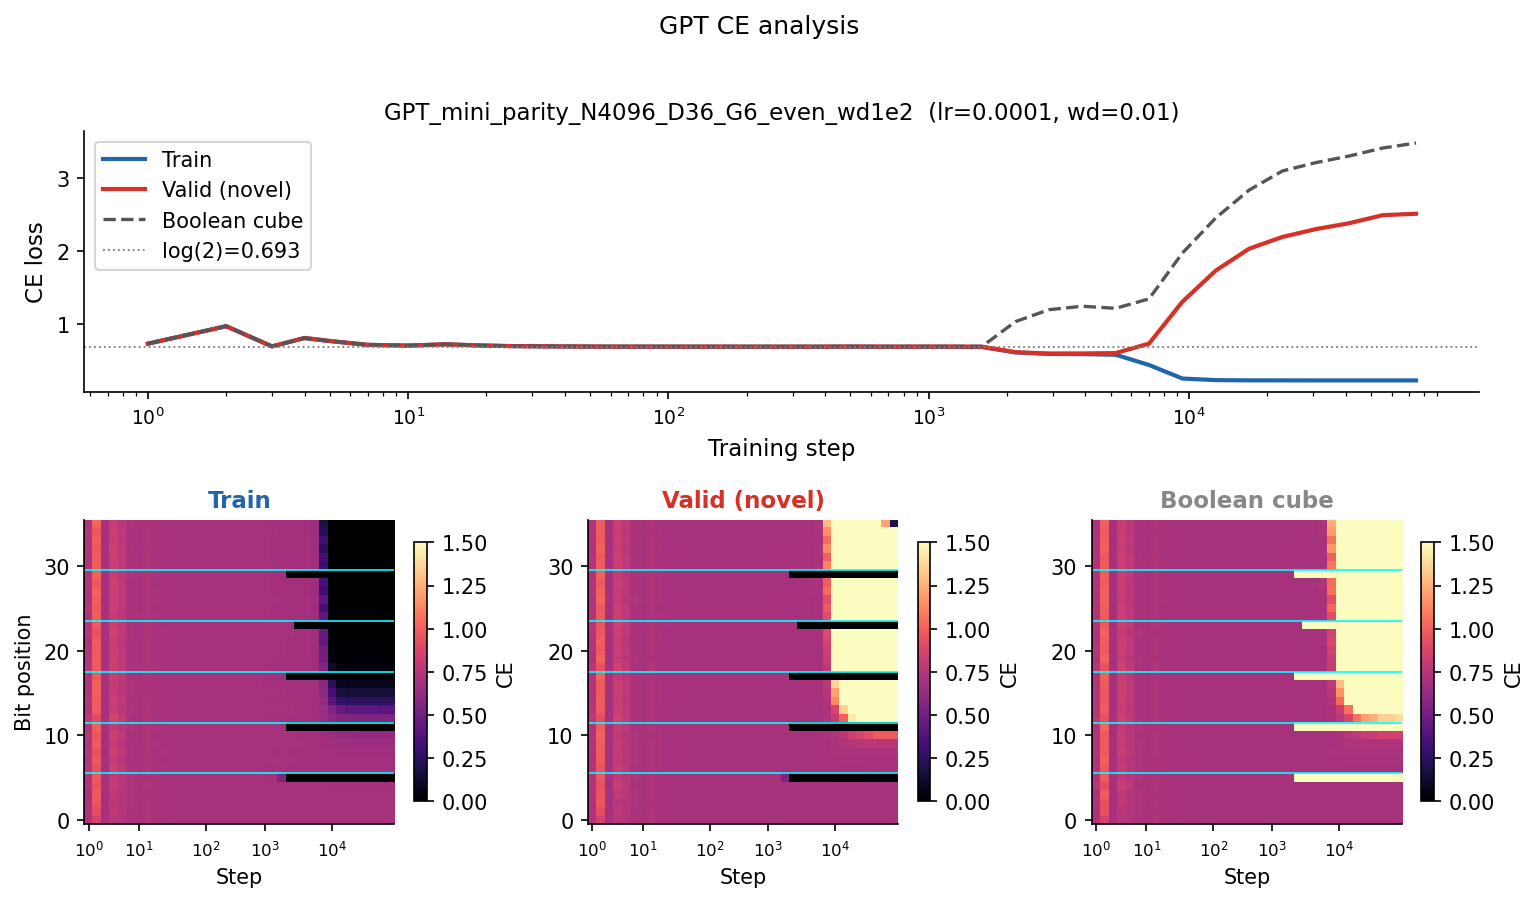

Saved → /n/home12/binxuwang/Github/DiffusionAttnConsistency/figures/GPT_parity_learn_dissection/GPT_G6_CE_analysis_G6_wd1e2.{pdf,png}


In [61]:
for exp_name in EXP_NAMES:
    exp_dir  = os.path.join(SAVEROOT, exp_name)
    short    = exp_name.replace("GPT_mini_parity_N4096_D36_", "").replace("_even", "")
    out_base = os.path.join(FIGDIR, f"GPT_G6_CE_analysis_{short}")
    fig = plot_ce_figure(exp_dir, group_size=GROUP_SIZE, n_eval=N_EVAL, vmax=1.5, figsize=(12, 6),)
    # fig.savefig(out_base + ".pdf", bbox_inches="tight")
    # fig.savefig(out_base + ".png", bbox_inches="tight", dpi=150)
    saveallforms(FIGDIR, f"GPT_G6_CE_analysis_{short}", fig)
    plt.show()
    print(f"Saved → {out_base}.{{pdf,png}}")

## Raw training stats (Accuracy, Mem Ratio) — log step scale

In [62]:
# Tags available in GPT tensorboard:
#   Eval/Sample_Accuracy   Eval/PerGroup_Accuracy
#   Eval/Sample_Mem_Ratio  Eval/BitGroup_Mem_Ratio
#   Training/Loss_Step     Training/Loss_Avg

STAT_TAGS = [
    "Eval/Sample_Accuracy",
    "Eval/PerGroup_Accuracy",
    "Eval/Sample_Mem_Ratio",
    "Eval/BitGroup_Mem_Ratio",
    "Training/Loss_Step",
]
STAT_LABELS = [
    "Sample Accuracy",
    "Per-Group Accuracy",
    "Sample Mem Ratio",
    "BitGroup Mem Ratio",
    "Train Loss (step)",
]
YHLINES = {
    "Eval/Sample_Accuracy":   0.9,
    "Eval/PerGroup_Accuracy": 0.9,
    "Eval/Sample_Mem_Ratio":  0.5,
    "Eval/BitGroup_Mem_Ratio":0.5,
}

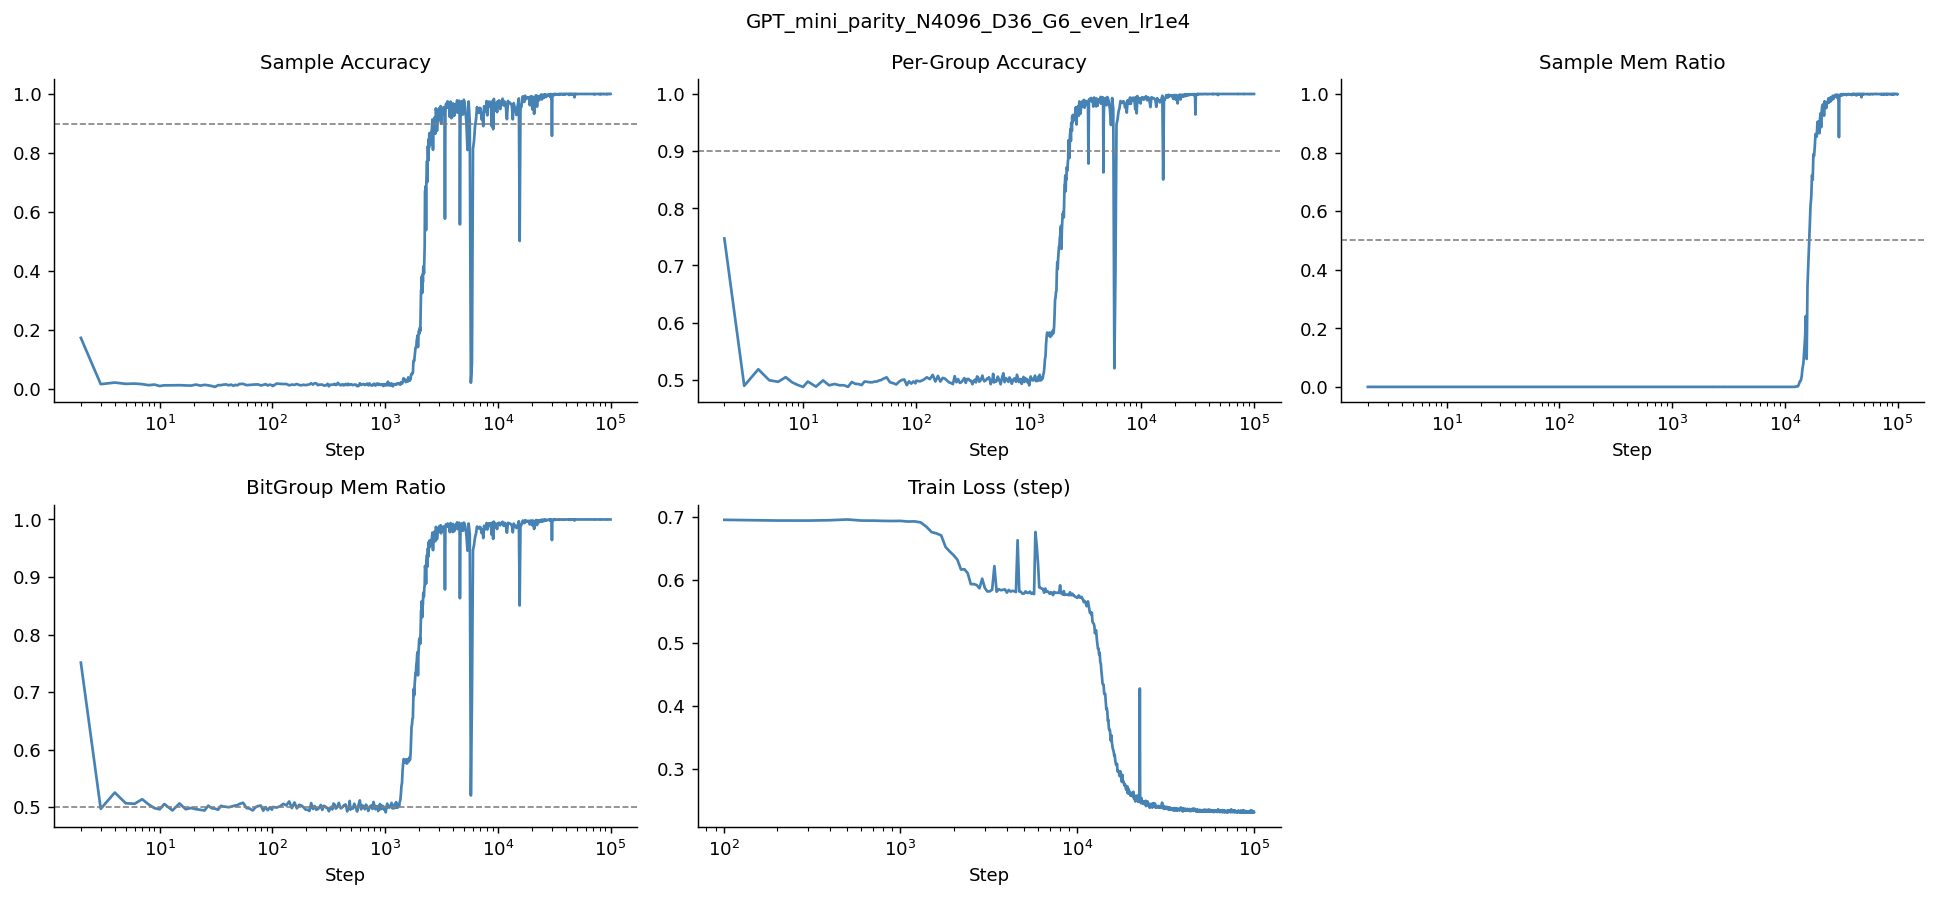

In [63]:
exp_name = EXP_NAMES[0]   # ← change me
exp_dir  = os.path.join(SAVEROOT, exp_name)
tb_dir   = os.path.join(exp_dir, "tensorboard")

tb_data = load_tb_scalars(tb_dir, STAT_TAGS)

ncols = 3
nrows = (len(STAT_TAGS) + ncols - 1) // ncols
fig, axes = plt.subplots(nrows, ncols, figsize=(5 * ncols, 3.5 * nrows), dpi=130)
axes = axes.flatten()

for i, (tag, lbl) in enumerate(zip(STAT_TAGS, STAT_LABELS)):
    ax = axes[i]
    if tag in tb_data:
        steps = np.array(tb_data[tag]["steps"])
        vals  = np.array(tb_data[tag]["vals"])
        ax.plot(steps + 1, vals, lw=1.5, color="steelblue")
    if tag in YHLINES:
        ax.axhline(YHLINES[tag], color="gray", lw=0.9, ls="--")
    ax.set_xscale("log")
    ax.set_title(lbl, fontsize=11)
    ax.set_xlabel("Step", fontsize=10)

# hide unused panels
for j in range(len(STAT_TAGS), len(axes)):
    axes[j].set_visible(False)

fig.suptitle(exp_name, fontsize=11)
plt.tight_layout()
plt.show()

### Variability across the two idenditcal runs

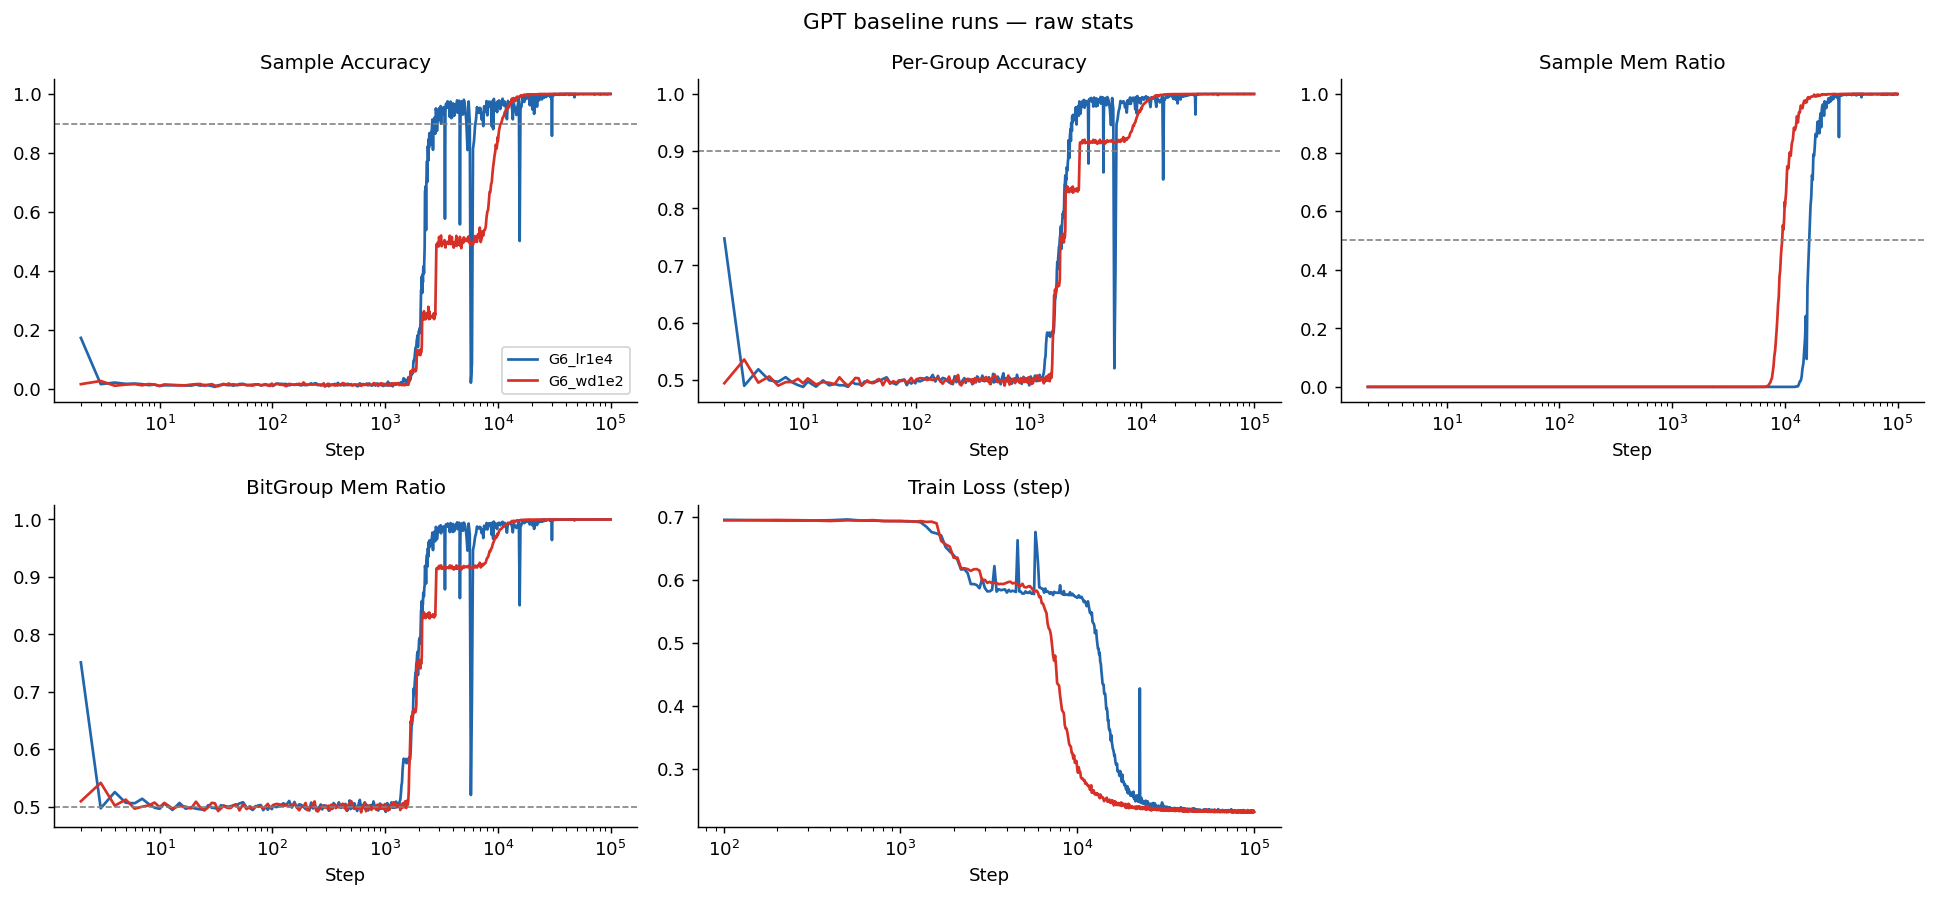

In [64]:
# ── Overlay two runs on the same axes for comparison ─────────────────────────
run_colors = ["#2166ac", "#d73027"]   # ← one colour per run

all_tb = {
    exp: load_tb_scalars(os.path.join(SAVEROOT, exp, "tensorboard"), STAT_TAGS)
    for exp in EXP_NAMES
}

ncols = 3
nrows = (len(STAT_TAGS) + ncols - 1) // ncols
fig, axes = plt.subplots(nrows, ncols, figsize=(5 * ncols, 3.5 * nrows), dpi=130)
axes = axes.flatten()

for i, (tag, lbl) in enumerate(zip(STAT_TAGS, STAT_LABELS)):
    ax = axes[i]
    for exp, col in zip(EXP_NAMES, run_colors):
        d = all_tb[exp]
        if tag in d:
            steps = np.array(d[tag]["steps"])
            vals  = np.array(d[tag]["vals"])
            short = exp.replace("GPT_mini_parity_N4096_D36_", "").replace("_even", "")
            ax.plot(steps + 1, vals, lw=1.5, color=col, label=short)
    if tag in YHLINES:
        ax.axhline(YHLINES[tag], color="gray", lw=0.9, ls="--")
    ax.set_xscale("log")
    ax.set_title(lbl, fontsize=11)
    ax.set_xlabel("Step", fontsize=10)
    if i == 0:
        ax.legend(fontsize=8)

for j in range(len(STAT_TAGS), len(axes)):
    axes[j].set_visible(False)

fig.suptitle("GPT baseline runs — raw stats", fontsize=12)
plt.tight_layout()
plt.show()

## Rule / Memorization onset bar charts — GPT & DiT sweeps

Onset defined as first sustained crossing (5 consecutive eval points above threshold):
- **Rule learning**: `Sample_Accuracy > 0.9`
- **Memorization**: `Sample_Mem_Ratio > 0.5`

Panels: LR sweep (top row) and WD sweep (bottom row), with GPT and DiT side by side.

In [65]:
def first_sustained_crossing(steps, vals, threshold, n_consec=5, above=True):
    """Return the step at which vals crosses threshold for n_consec consecutive points.
    Returns np.nan if never reached."""
    steps = np.asarray(steps)
    vals  = np.asarray(vals)
    mask  = vals > threshold if above else vals < threshold
    count = 0
    for i, m in enumerate(mask):
        if m:
            count += 1
            if count >= n_consec:
                return steps[i - n_consec + 1]
        else:
            count = 0
    return np.nan


def get_onsets(exp_name, saveroot, acc_thresh=0.9, mem_thresh=0.5, n_consec=5):
    """Load TB and return (rule_onset_step, mem_onset_step)."""
    tb_dir = os.path.join(saveroot, exp_name, "tensorboard")
    if not os.path.isdir(tb_dir):
        return np.nan, np.nan
    d = load_tb_scalars(tb_dir, ["Eval/Sample_Accuracy", "Eval/Sample_Mem_Ratio"])
    rule = np.nan
    mem  = np.nan
    if "Eval/Sample_Accuracy" in d:
        s = np.array(d["Eval/Sample_Accuracy"]["steps"])
        v = np.array(d["Eval/Sample_Accuracy"]["vals"])
        rule = first_sustained_crossing(s, v, acc_thresh, n_consec)
    if "Eval/Sample_Mem_Ratio" in d:
        s = np.array(d["Eval/Sample_Mem_Ratio"]["steps"])
        v = np.array(d["Eval/Sample_Mem_Ratio"]["vals"])
        mem = first_sustained_crossing(s, v, mem_thresh, n_consec)
    return rule, mem

In [66]:
# ── Experiment lists ──────────────────────────────────────────────────────────

# GPT LR sweep (wd=0.01, 100k steps)
GPT_LR_EXPS  = [
    (1e-5, "GPT_mini_parity_N4096_D36_G6_even_lr1e5"),
    (3e-5, "GPT_mini_parity_N4096_D36_G6_even_lr3e5"),
    (1e-4, "GPT_mini_parity_N4096_D36_G6_even_lr1e4"),
    (3e-4, "GPT_mini_parity_N4096_D36_G6_even_lr3e4"),
    (1e-3, "GPT_mini_parity_N4096_D36_G6_even_lr1e3"),
    (3e-3, "GPT_mini_parity_N4096_D36_G6_even_lr3e3"),
]

# GPT WD sweep (lr=1e-4, 100k steps)
GPT_WD_EXPS  = [
    (0,    "GPT_mini_parity_N4096_D36_G6_even_wd0"),
    (1e-3, "GPT_mini_parity_N4096_D36_G6_even_wd1e3"),
    (1e-2, "GPT_mini_parity_N4096_D36_G6_even_wd1e2"),
    (5e-2, "GPT_mini_parity_N4096_D36_G6_even_wd5e2"),
    (3e-1, "GPT_mini_parity_N4096_D36_G6_even_wd3e1"),
    (1e0,  "GPT_mini_parity_N4096_D36_G6_even_wd1e0"),
    (1e1,  "GPT_mini_parity_N4096_D36_G6_even_wd1e1"),
]

# DiT LR sweep (wd=0, Adam, 1M steps)
DIT_LR_EXPS  = [
    (1e-5, "DiT_mini_parity_N4096_D36_G6_even_lr1e5"),
    (3e-5, "DiT_mini_parity_N4096_D36_G6_even_lr3e5"),
    (1e-4, "DiT_mini_parity_N4096_D36_G6_even_lr1e4"),
    (3e-4, "DiT_mini_parity_N4096_D36_G6_even_lr3e4"),
    (1e-3, "DiT_mini_parity_N4096_D36_G6_even_lr1e3"),
    (3e-3, "DiT_mini_parity_N4096_D36_G6_even_lr3e3"),
]

# DiT WD sweep (lr=1e-4, AdamW, 1M steps)
DIT_WD_EXPS  = [
    (1e-6, "DiT_mini_parity_N4096_D36_G6_even_wd1e6"),
    (1e-5, "DiT_mini_parity_N4096_D36_G6_even_wd1e5"),
    (1e-4, "DiT_mini_parity_N4096_D36_G6_even_wd1e4"),
    (1e-3, "DiT_mini_parity_N4096_D36_G6_even_wd1e3"),
    (1e-2, "DiT_mini_parity_N4096_D36_G6_even_wd1e2"),
    (5e-2, "DiT_mini_parity_N4096_D36_G6_even_wd5e2"),
]

In [67]:
# ── Compute onsets ────────────────────────────────────────────────────────────
N_CONSEC   = 5
GPT_MAX_STEP = 1e5   # GPT trained 100k steps
DIT_MAX_STEP = 1e6   # DiT trained 1M steps

def collect_onsets(exp_list, saveroot, max_step):
    params, rules, mems = [], [], []
    for param_val, exp_name in exp_list:
        r, m = get_onsets(exp_name, saveroot, n_consec=N_CONSEC)
        params.append(param_val)
        rules.append(r if not np.isnan(r) else max_step)
        mems.append(m  if not np.isnan(m)  else max_step)
    return np.array(params), np.array(rules), np.array(mems)

gpt_lr_params, gpt_lr_rule, gpt_lr_mem = collect_onsets(GPT_LR_EXPS, SAVEROOT, GPT_MAX_STEP)
gpt_wd_params, gpt_wd_rule, gpt_wd_mem = collect_onsets(GPT_WD_EXPS, SAVEROOT, GPT_MAX_STEP)
dit_lr_params, dit_lr_rule, dit_lr_mem = collect_onsets(DIT_LR_EXPS, SAVEROOT, DIT_MAX_STEP)
dit_wd_params, dit_wd_rule, dit_wd_mem = collect_onsets(DIT_WD_EXPS, SAVEROOT, DIT_MAX_STEP)

print("GPT LR rule:", gpt_lr_rule)
print("GPT LR mem: ", gpt_lr_mem)
print("DiT LR rule:", dit_lr_rule)
print("DiT LR mem: ", dit_lr_mem)

GPT LR rule: [ 13328.   8328.   2916.   7304. 100000. 100000.]
GPT LR mem:  [ 47376.  15632.  16656.   6024. 100000. 100000.]
DiT LR rule: [ 615072.  229024.  191136.  665248. 1000000. 1000000.]
DiT LR mem:  [1000000. 1000000. 1000000. 1000000. 1000000. 1000000.]


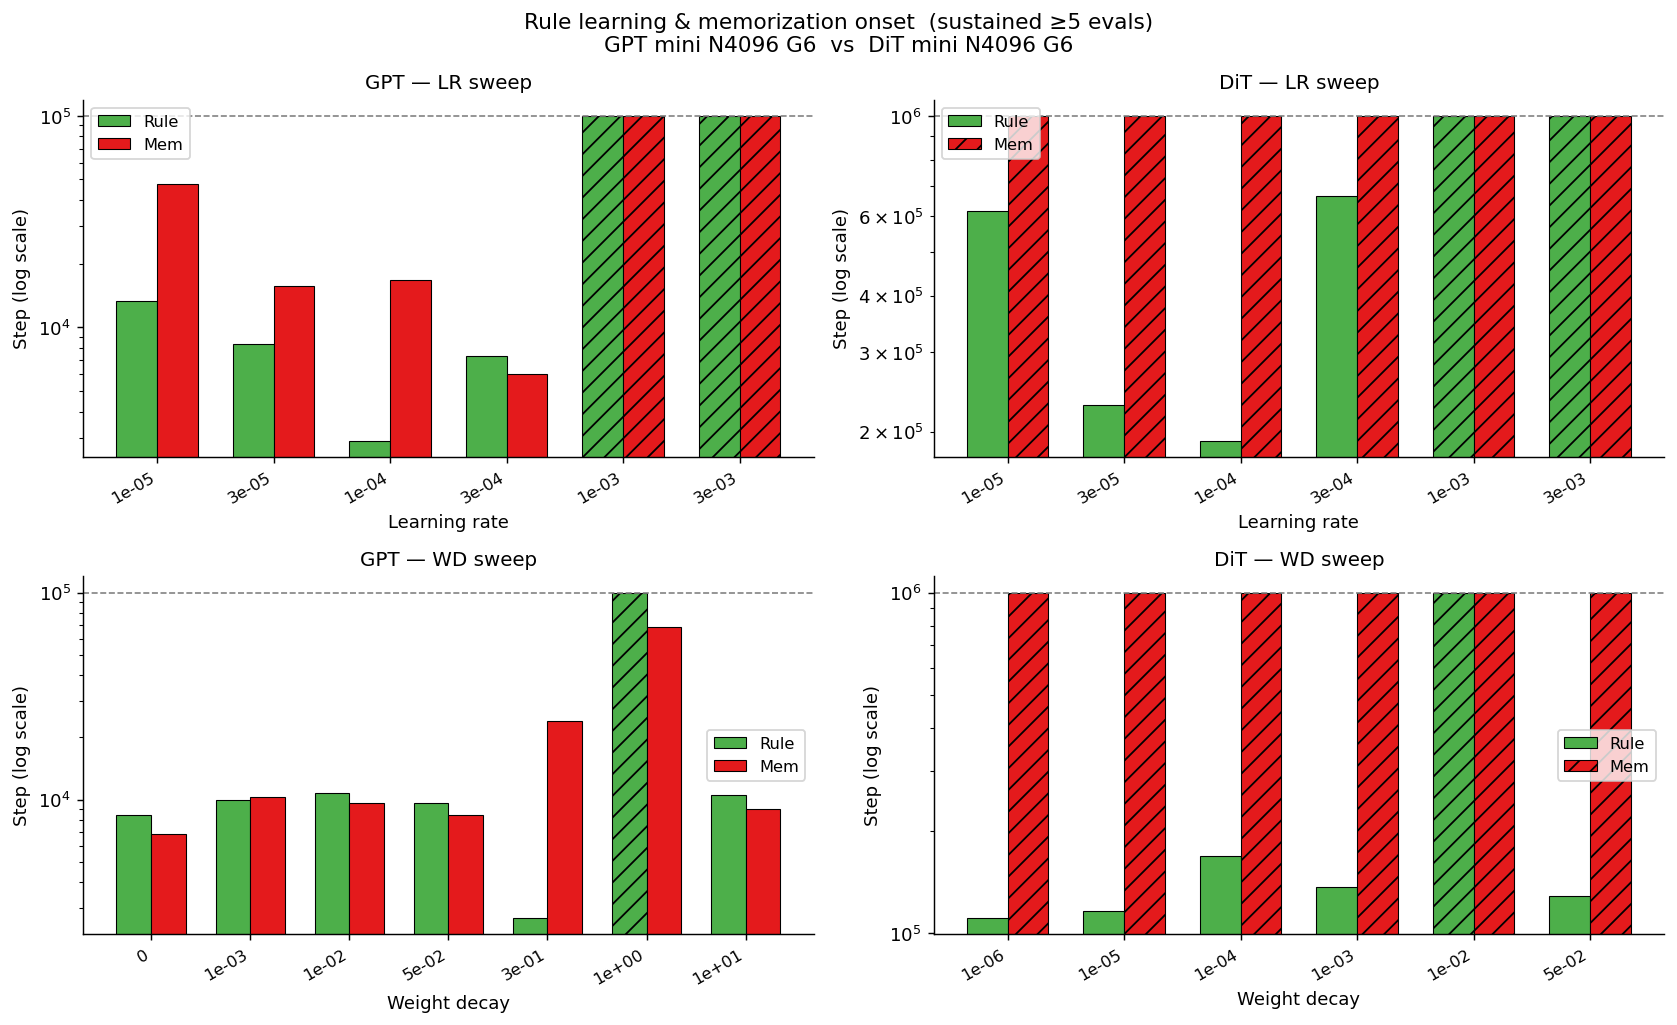

Saved → /n/home12/binxuwang/Github/DiffusionAttnConsistency/figures/GPT_parity_learn_dissection/GPT_DiT_G6_rule_mem_onset_barplot.{pdf,png}


In [68]:
def bar_onset(ax, params, rule_steps, mem_steps, max_step, xlabel, title_prefix, bar_width=0.35):
    """Plot rule + mem onset bars side by side on a log-y axis."""
    x  = np.arange(len(params))
    xlabels = [f"{p:.0e}" if p > 0 else "0" for p in params]

    # hatching = not reached (capped at max_step)
    rule_reached = ~np.isclose(rule_steps, max_step)
    mem_reached  = ~np.isclose(mem_steps,  max_step)

    for i, (rs, ms, rr, mr) in enumerate(zip(rule_steps, mem_steps, rule_reached, mem_reached)):
        hatch_r = "" if rr else "//"
        hatch_m = "" if mr else "//"
        ax.bar(x[i] - bar_width/2, rs, bar_width, color="#4daf4a", hatch=hatch_r,
               edgecolor="k", linewidth=0.6, label="Rule" if i == 0 else "")
        ax.bar(x[i] + bar_width/2, ms, bar_width, color="#e41a1c", hatch=hatch_m,
               edgecolor="k", linewidth=0.6, label="Mem"  if i == 0 else "")

    ax.axhline(max_step, color="gray", lw=0.9, ls="--")
    ax.set_yscale("log")
    ax.set_xticks(x)
    ax.set_xticklabels(xlabels, rotation=30, ha="right", fontsize=9)
    ax.set_xlabel(xlabel, fontsize=10)
    ax.set_ylabel("Step (log scale)", fontsize=10)
    ax.set_title(title_prefix, fontsize=11)
    ax.legend(fontsize=9)


fig, axes = plt.subplots(2, 2, figsize=(13, 8), dpi=130)

bar_onset(axes[0, 0], gpt_lr_params, gpt_lr_rule, gpt_lr_mem, GPT_MAX_STEP,
          "Learning rate", "GPT — LR sweep")
bar_onset(axes[0, 1], dit_lr_params, dit_lr_rule, dit_lr_mem, DIT_MAX_STEP,
          "Learning rate", "DiT — LR sweep")
bar_onset(axes[1, 0], gpt_wd_params, gpt_wd_rule, gpt_wd_mem, GPT_MAX_STEP,
          "Weight decay",  "GPT — WD sweep")
bar_onset(axes[1, 1], dit_wd_params, dit_wd_rule, dit_wd_mem, DIT_MAX_STEP,
          "Weight decay",  "DiT — WD sweep")

fig.suptitle(
    "Rule learning & memorization onset  (sustained ≥5 evals)\n"
    "GPT mini N4096 G6  vs  DiT mini N4096 G6",
    fontsize=12,
)
plt.tight_layout()

out_base = os.path.join(FIGDIR, "GPT_DiT_G6_rule_mem_onset_barplot")
fig.savefig(out_base + ".pdf", bbox_inches="tight")
fig.savefig(out_base + ".png", bbox_inches="tight", dpi=150)
plt.show()
print(f"Saved → {out_base}.{{pdf,png}}")

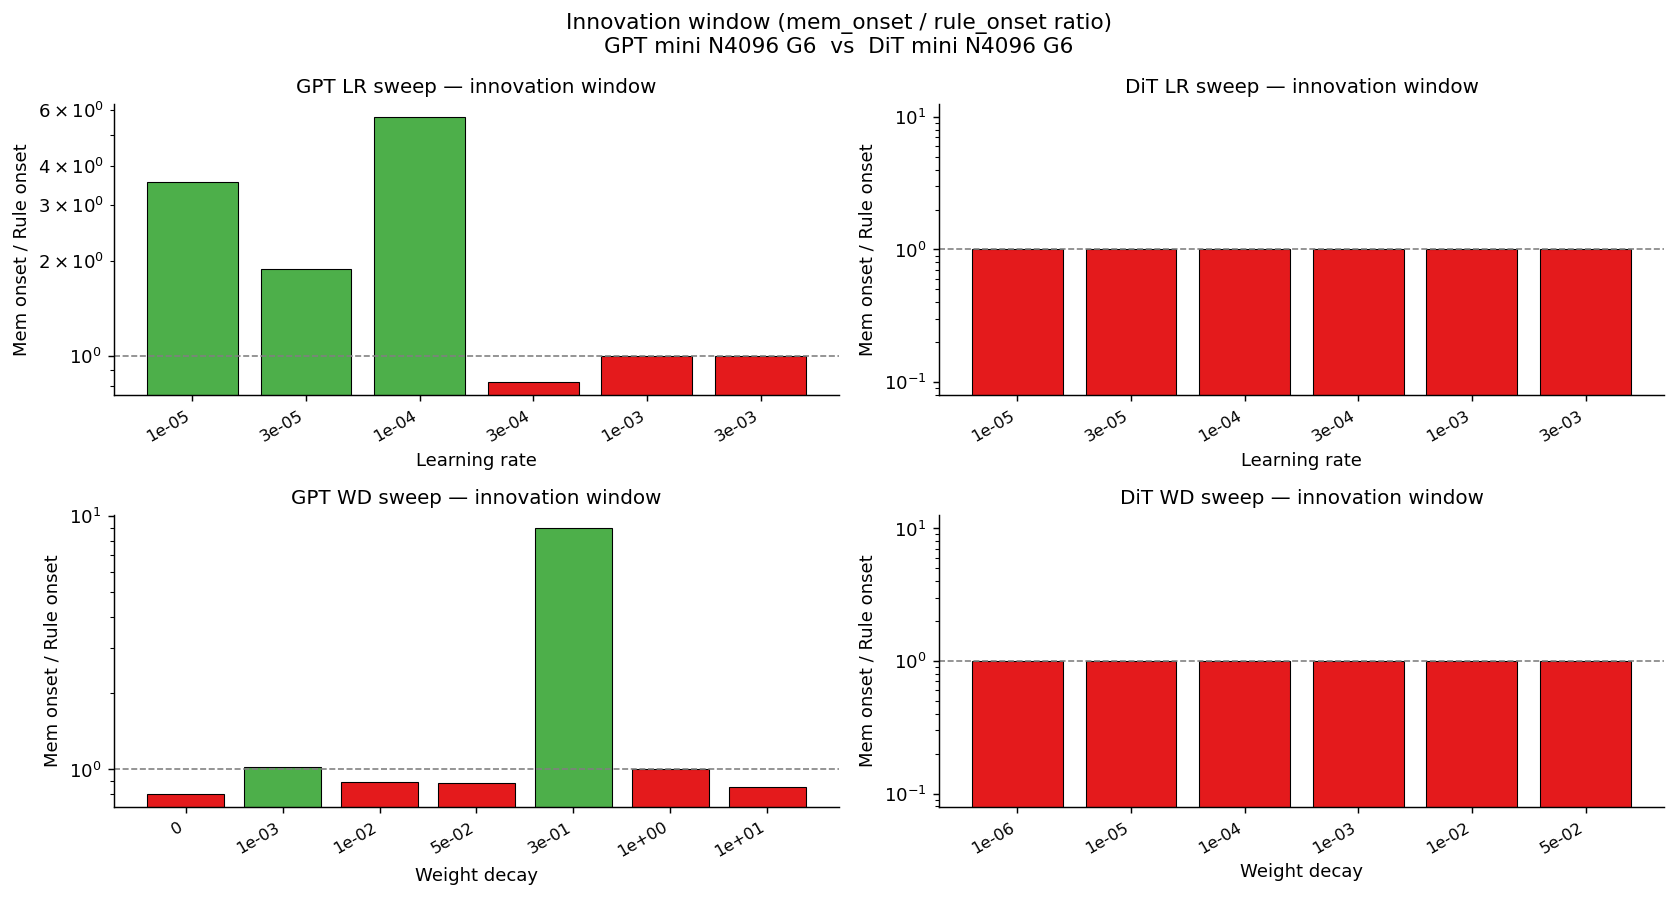

In [69]:
# ── Innovation window: gap between rule onset and memorization onset ──────────
# Positive = rule learned before mem takes over (healthy grokking window)
# Only plot where both are finite

def bar_innovation(ax, params, rule_steps, mem_steps, max_step, xlabel, title):
    x       = np.arange(len(params))
    xlabels = [f"{p:.0e}" if p > 0 else "0" for p in params]
    both_ok = ~(np.isclose(rule_steps, max_step) | np.isclose(mem_steps, max_step))
    gaps    = np.where(both_ok, mem_steps / np.maximum(rule_steps, 1), np.nan)

    colors = ["#4daf4a" if g >= 1 else "#e41a1c" for g in np.nan_to_num(gaps, nan=0)]
    bars   = ax.bar(x, np.nan_to_num(gaps, nan=1), color=colors, edgecolor="k", linewidth=0.6)
    ax.axhline(1, color="gray", lw=0.9, ls="--")
    ax.set_yscale("log")
    ax.set_xticks(x)
    ax.set_xticklabels(xlabels, rotation=30, ha="right", fontsize=9)
    ax.set_xlabel(xlabel, fontsize=10)
    ax.set_ylabel("Mem onset / Rule onset", fontsize=10)
    ax.set_title(title, fontsize=11)


fig, axes = plt.subplots(2, 2, figsize=(13, 7), dpi=130)

bar_innovation(axes[0, 0], gpt_lr_params, gpt_lr_rule, gpt_lr_mem, GPT_MAX_STEP,
               "Learning rate", "GPT LR sweep — innovation window")
bar_innovation(axes[0, 1], dit_lr_params, dit_lr_rule, dit_lr_mem, DIT_MAX_STEP,
               "Learning rate", "DiT LR sweep — innovation window")
bar_innovation(axes[1, 0], gpt_wd_params, gpt_wd_rule, gpt_wd_mem, GPT_MAX_STEP,
               "Weight decay",  "GPT WD sweep — innovation window")
bar_innovation(axes[1, 1], dit_wd_params, dit_wd_rule, dit_wd_mem, DIT_MAX_STEP,
               "Weight decay",  "DiT WD sweep — innovation window")

fig.suptitle(
    "Innovation window (mem_onset / rule_onset ratio)\n"
    "GPT mini N4096 G6  vs  DiT mini N4096 G6",
    fontsize=12,
)
plt.tight_layout()
plt.show()

## Rule / Mem onset heatmap across G sizes — GPT vs DiT N=4096
Rows = group size G, columns = GPT | DiT.
Color = log10(onset step). Gray/saturated = not reached within training budget.

## Dynamics heatmap: valid fraction & mem ratio over log steps × G
x-axis = log training step, y-axis = G, color = metric value.
Shows the *trajectory* rather than just the onset time.

In [70]:
from scipy.interpolate import interp1d

def build_timeheatmap(exp_list, saveroot, log_step_grid=None, n_grid=300):
    """
    Load eval time series for each (G, exp_name) and interpolate onto a
    shared log-step grid.

    Returns
    -------
    log_grid   : (n_grid,)   — log10(step) values
    acc_mat    : (n_G, n_grid)
    mem_mat    : (n_G, n_grid)
    g_labels   : list of G values
    """
    all_acc, all_mem, g_labels = [], [], []

    for G, exp_name in exp_list:
        ts = load_eval_timeseries(exp_name, saveroot)
        if ts is None or len(ts["eval_steps"]) == 0:
            all_acc.append(None); all_mem.append(None)
        else:
            all_acc.append((ts["eval_steps"], ts["valid_acc"]))
            all_mem.append((ts["eval_steps"], ts["mem_ratio"]))
        g_labels.append(G)

    # Build shared log grid from all available step ranges
    all_steps = [s for s, _ in all_acc if s is not None]
    smin = min(s.min() for s in all_steps)
    smax = max(s.max() for s in all_steps)
    log_grid = np.linspace(np.log10(smin), np.log10(smax), n_grid)
    step_grid = 10 ** log_grid

    def interp_row(data, fill=np.nan):
        if data is None:
            return np.full(n_grid, fill)
        steps, vals = data
        # clip to avoid extrapolation artifacts
        f = interp1d(steps, vals, bounds_error=False, fill_value=(vals[0], vals[-1]))
        return f(step_grid)

    acc_mat = np.array([interp_row(d) for d in all_acc])
    mem_mat = np.array([interp_row(d, fill=0) for d in all_mem])
    return log_grid, acc_mat, mem_mat, g_labels


def plot_dynamics_heatmap(model_exp_lists, saveroot, n_grid=300,
                          figsize=None, save_path=None, dpi=150):
    """
    Plot valid-fraction and mem-ratio dynamics heatmaps for multiple models.

    Parameters
    ----------
    model_exp_lists : list of (label, exp_list, max_step)
        exp_list : list of (G, exp_name) pairs
    """
    n_models = len(model_exp_lists)
    if figsize is None:
        figsize = (6 * 3, 3 * n_models)   # 3 cols × n_model rows

    fig, axes = plt.subplots(n_models, 3, figsize=figsize, dpi=dpi,
                             squeeze=False)

    for row, (label, exp_list, max_step) in enumerate(model_exp_lists):
        log_grid, acc_mat, mem_mat, g_labels = build_timeheatmap(
            exp_list, saveroot, n_grid=n_grid)
        innov_mat = np.clip(acc_mat - mem_mat, 0, 1)

        n_G   = len(g_labels)
        extent = [log_grid[0], log_grid[-1], -0.5, n_G - 0.5]

        def decade_ticks_from_log(log_grid):
            lo = int(np.floor(log_grid[0]))
            hi = int(np.ceil(log_grid[-1]))
            ticks_log  = [p for p in range(lo, hi + 1)]
            ticks_step = [10**p for p in ticks_log]
            labels     = [f"$10^{{{p}}}$" for p in ticks_log]
            return ticks_log, labels

        tick_locs, tick_labs = decade_ticks_from_log(log_grid)

        for col, (mat, title, cmap, vmin, vmax_) in enumerate([
            (acc_mat,   "Valid fraction",  "YlGnBu",  0, 1),
            (mem_mat,   "Mem ratio",       "YlOrRd",  0, 1),
            (innov_mat, "Innovation\n(valid − mem)", "Blues", 0, 1),
        ]):
            ax = axes[row, col]
            im = ax.imshow(mat, aspect="auto", origin="lower",
                           extent=extent, cmap=cmap,
                           vmin=vmin, vmax=vmax_, interpolation="nearest")
            ax.set_xticks(tick_locs)
            ax.set_xticklabels(tick_labs, fontsize=8)
            ax.set_yticks(range(n_G))
            ax.set_yticklabels([f"G={G}" for G in g_labels], fontsize=8)
            ax.set_xlabel("Step", fontsize=9)
            if col == 0:
                ax.set_ylabel(label, fontsize=10, fontweight="bold")
            if row == 0:
                ax.set_title(title, fontsize=11)
            plt.colorbar(im, ax=ax, shrink=0.8)

    plt.tight_layout()
    if save_path:
        fig.savefig(save_path + ".pdf", bbox_inches="tight")
        fig.savefig(save_path + ".png", bbox_inches="tight", dpi=dpi)
        print(f"Saved → {save_path}.{{pdf,png}}")
    return fig

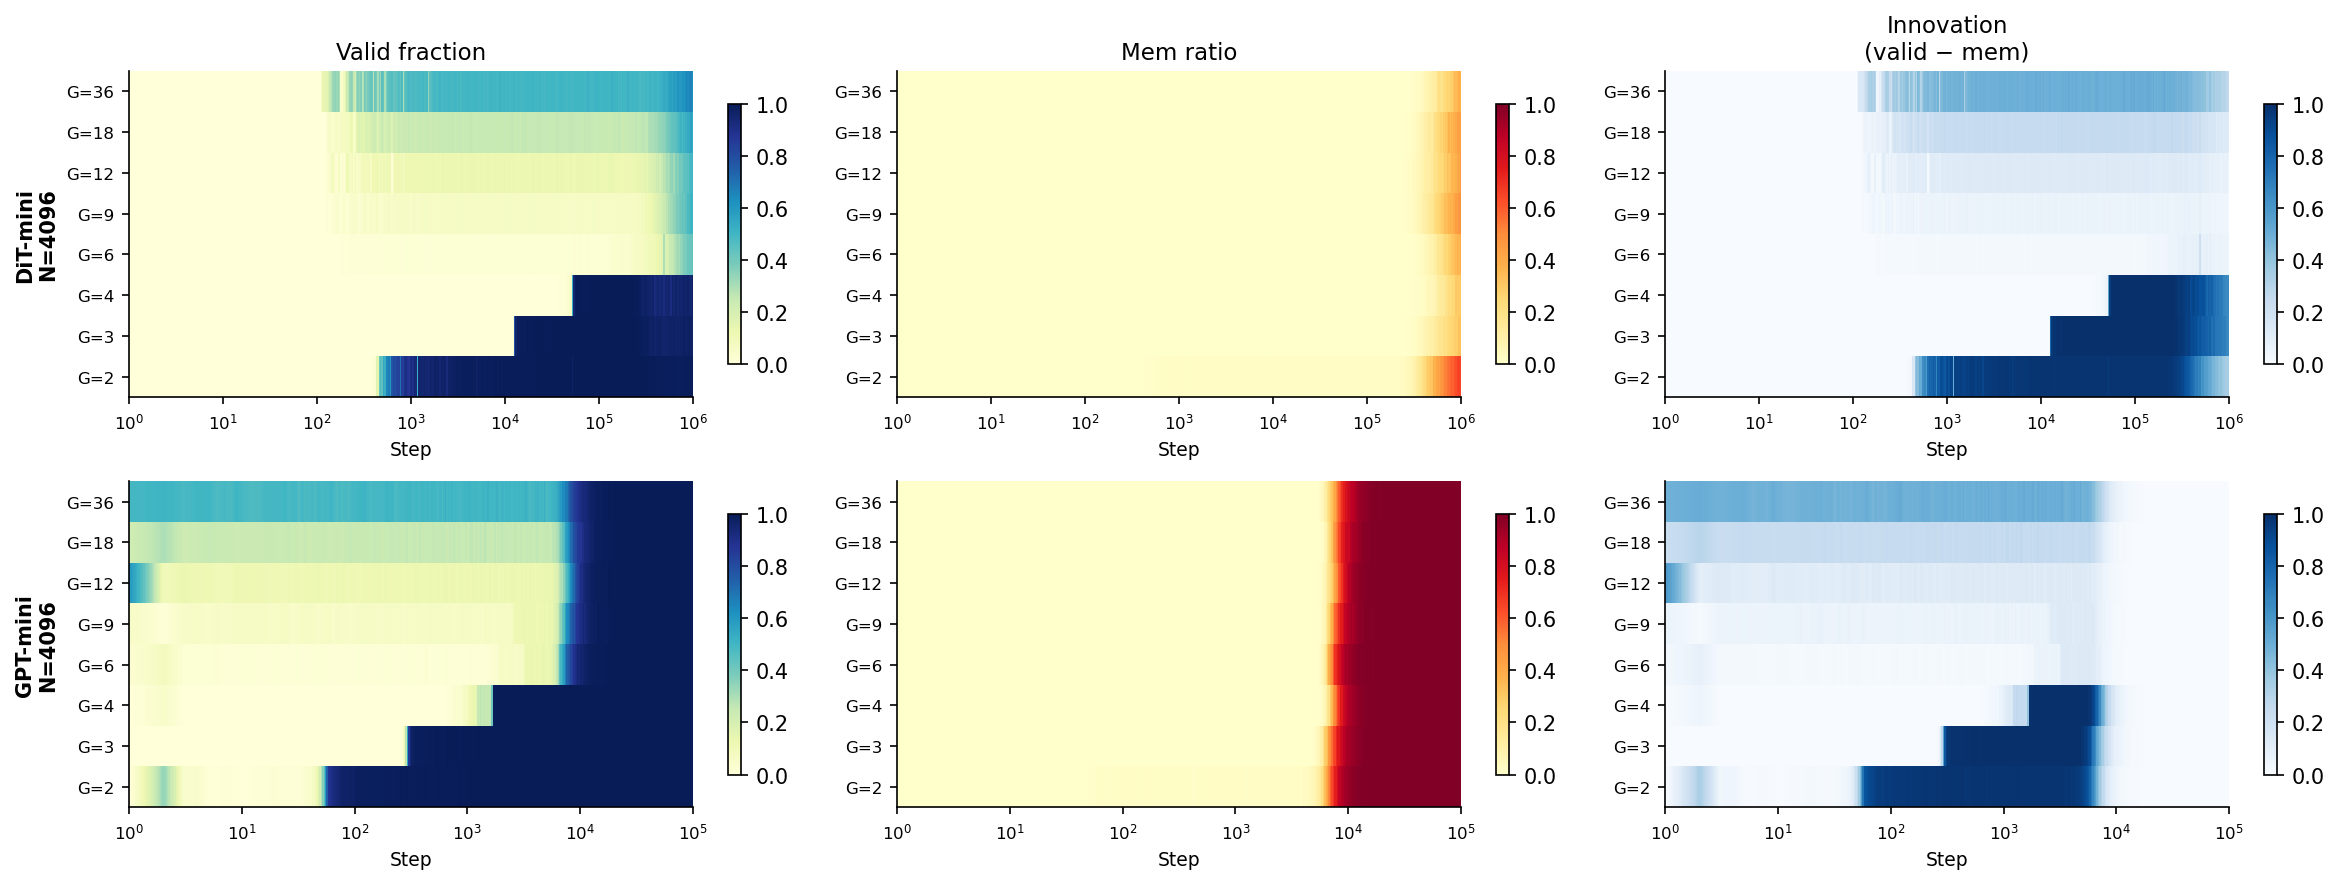

Saved → /n/home12/binxuwang/Github/DiffusionAttnConsistency/figures/GPT_parity_learn_dissection/GPT_DiT_N4096_dynamics_heatmap_G.{pdf,png}


In [71]:
G_VALS = [2, 3, 4, 6, 9, 12, 18, 36]

model_exp_lists = [
    ("DiT-mini\nN=4096", [(G, f"DiT_mini_parity_N4096_D36_G{G}_even") for G in G_VALS], 1e6),
    ("GPT-mini\nN=4096", [(G, f"GPT_mini_parity_N4096_D36_G{G}_even") for G in G_VALS], 1e5),
]

fig = plot_dynamics_heatmap(model_exp_lists, SAVEROOT, n_grid=400,
                             figsize=(16, 6))

out_base = os.path.join(FIGDIR, "GPT_DiT_N4096_dynamics_heatmap_G")
fig.savefig(out_base + ".pdf", bbox_inches="tight")
fig.savefig(out_base + ".png", bbox_inches="tight", dpi=150)
plt.show()
print(f"Saved → {out_base}.{{pdf,png}}")

In [72]:
from core.onset_lib import first_sustained_crossing, get_onsets, collect_onsets

In [73]:
from matplotlib.colors import LogNorm
N_CONSEC = 10
G_VALS  = [2, 3, 4, 6, 9, 12, 18, 36]
MODELS  = [("GPT_mini", 1e5), ("DiT_mini", 1e6)]   # (prefix, max_step)

# ── Collect onsets for all G × model ─────────────────────────────────────────
rule_mat = np.full((len(G_VALS), len(MODELS)), np.nan)
mem_mat  = np.full((len(G_VALS), len(MODELS)), np.nan)

for mi, (model_prefix, max_step) in enumerate(MODELS):
    for gi, G in enumerate(G_VALS):
        exp = f"{model_prefix}_parity_N4096_D36_G{G}_even"
        r, m = get_onsets(exp, SAVEROOT, n_consec=N_CONSEC, acc_thresh=0.9, mem_thresh=0.1)
        rule_mat[gi, mi] = r if not np.isnan(r) else max_step
        mem_mat[gi,  mi] = m if not np.isnan(m) else max_step

print("Rule onset (rows=G, cols=GPT/DiT):")
print(rule_mat)
print("Mem onset:")
print(mem_mat)

Rule onset (rows=G, cols=GPT/DiT):
[[6.2000e+01 1.2040e+03]
 [3.0800e+02 1.3072e+04]
 [1.7000e+03 5.4608e+04]
 [9.3520e+03 1.0000e+06]
 [1.0000e+04 1.0000e+06]
 [1.0256e+04 1.0000e+06]
 [1.0768e+04 1.0000e+06]
 [1.0256e+04 1.0000e+06]]
Mem onset:
[[  5512. 339616.]
 [  5896. 479904.]
 [  6408. 587424.]
 [  6280. 521888.]
 [  6408. 411296.]
 [  6408. 438944.]
 [  6664. 430752.]
 [  6280. 481952.]]


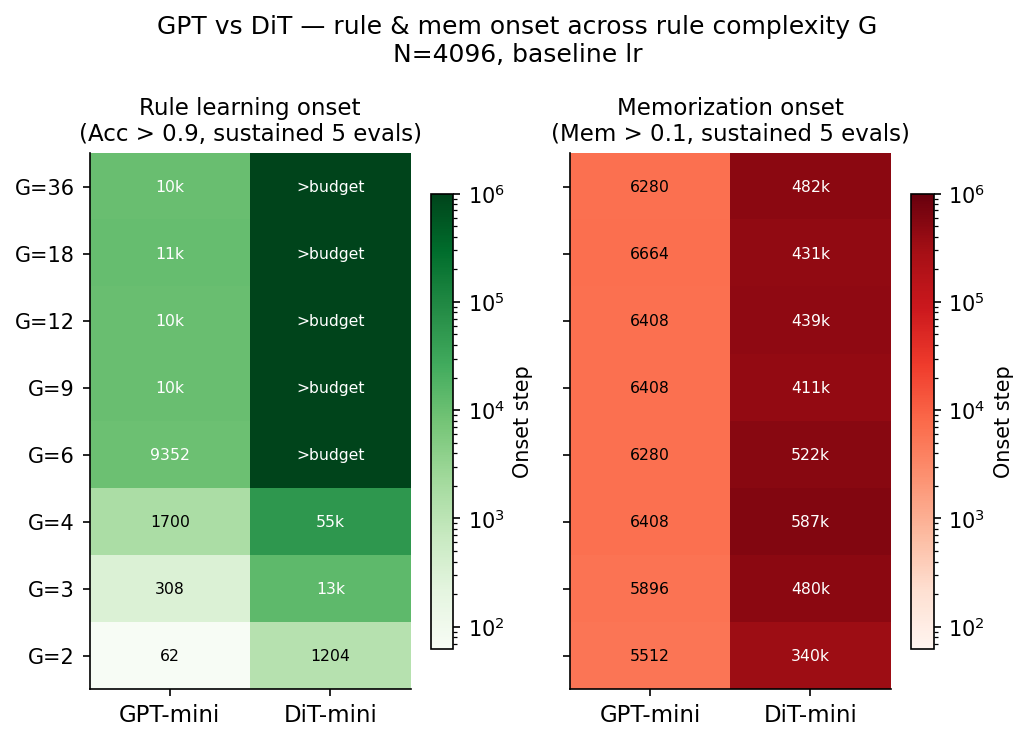

Saved → /n/home12/binxuwang/Github/DiffusionAttnConsistency/figures/GPT_parity_learn_dissection/GPT_DiT_N4096_onset_heatmap_across_G.{pdf,png}


In [74]:
model_labels = [p.replace("_mini", "-mini") for p, _ in MODELS]

# Shared log-norm so rule and mem panels are colour-comparable
all_vals = np.concatenate([rule_mat.ravel(), mem_mat.ravel()])
lnorm    = LogNorm(vmin=np.nanmin(all_vals[all_vals > 0]),
                   vmax=np.nanmax(all_vals))

fig, axes = plt.subplots(1, 2, figsize=(7, 5), dpi=150, sharey=True)

for ax, mat, title, cmap in [
    (axes[0], rule_mat, "Rule learning onset\n(Acc > 0.9, sustained 5 evals)", "Greens"),
    (axes[1], mem_mat,  "Memorization onset\n(Mem > 0.1, sustained 5 evals)",  "Reds"),
]:
    im = ax.imshow(mat, aspect="auto", origin="lower",
                   cmap=cmap, norm=lnorm, interpolation="nearest")

    # Annotate each cell
    mid = np.sqrt(lnorm.vmin * lnorm.vmax)
    for gi in range(len(G_VALS)):
        for mi in range(len(MODELS)):
            v   = mat[gi, mi]
            txt = f"{v:.0f}" if v < 1e4 else (f"{v/1e3:.0f}k" if v < 1e6 else ">budget")
            ax.text(mi, gi, txt, ha="center", va="center", fontsize=7.5,
                    color="white" if v > mid else "black")

    ax.set_xticks(range(len(MODELS)))
    ax.set_xticklabels(model_labels, fontsize=11)
    ax.set_yticks(range(len(G_VALS)))
    ax.set_yticklabels([f"G={G}" for G in G_VALS], fontsize=10)
    ax.set_title(title, fontsize=11)
    plt.colorbar(im, ax=ax, label="Onset step", shrink=0.85)

fig.suptitle("GPT vs DiT — rule & mem onset across rule complexity G\nN=4096, baseline lr", fontsize=12)
plt.tight_layout()

out_base = os.path.join(FIGDIR, "GPT_DiT_N4096_onset_heatmap_across_G")
saveallforms(FIGDIR, "GPT_DiT_N4096_onset_heatmap_across_G", fig)
# fig.savefig(out_base + ".pdf", bbox_inches="tight")
# fig.savefig(out_base + ".png", bbox_inches="tight", dpi=150)
plt.show()
print(f"Saved → {out_base}.{{pdf,png}}")

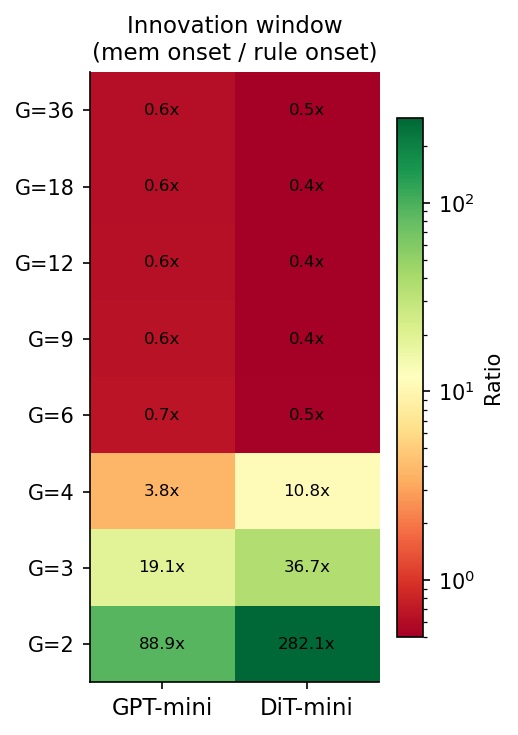

In [75]:
# ── Innovation window heatmap: mem_onset / rule_onset ─────────────────────────
innov_mat = mem_mat / np.maximum(rule_mat, 1)

fig, ax = plt.subplots(1, 1, figsize=(3.5, 5), dpi=150)
im = ax.imshow(innov_mat, aspect="auto", origin="lower",
               norm=LogNorm(vmin=max(innov_mat.min(), 0.5), vmax=innov_mat.max()),
               cmap="RdYlGn", interpolation="nearest")

for gi in range(len(G_VALS)):
    for mi in range(len(MODELS)):
        ax.text(mi, gi, f"{innov_mat[gi, mi]:.1f}x",
                ha="center", va="center", fontsize=8)

ax.set_xticks(range(len(MODELS)))
ax.set_xticklabels(model_labels, fontsize=11)
ax.set_yticks(range(len(G_VALS)))
ax.set_yticklabels([f"G={G}" for G in G_VALS], fontsize=10)
ax.set_title("Innovation window\n(mem onset / rule onset)", fontsize=11)
plt.colorbar(im, ax=ax, label="Ratio", shrink=0.85)
plt.tight_layout()
plt.show()

## Interactive / custom CE tweaking
Copy-paste the cell below and modify as needed.

NameError: name 'HMAP_CMAPS' is not defined

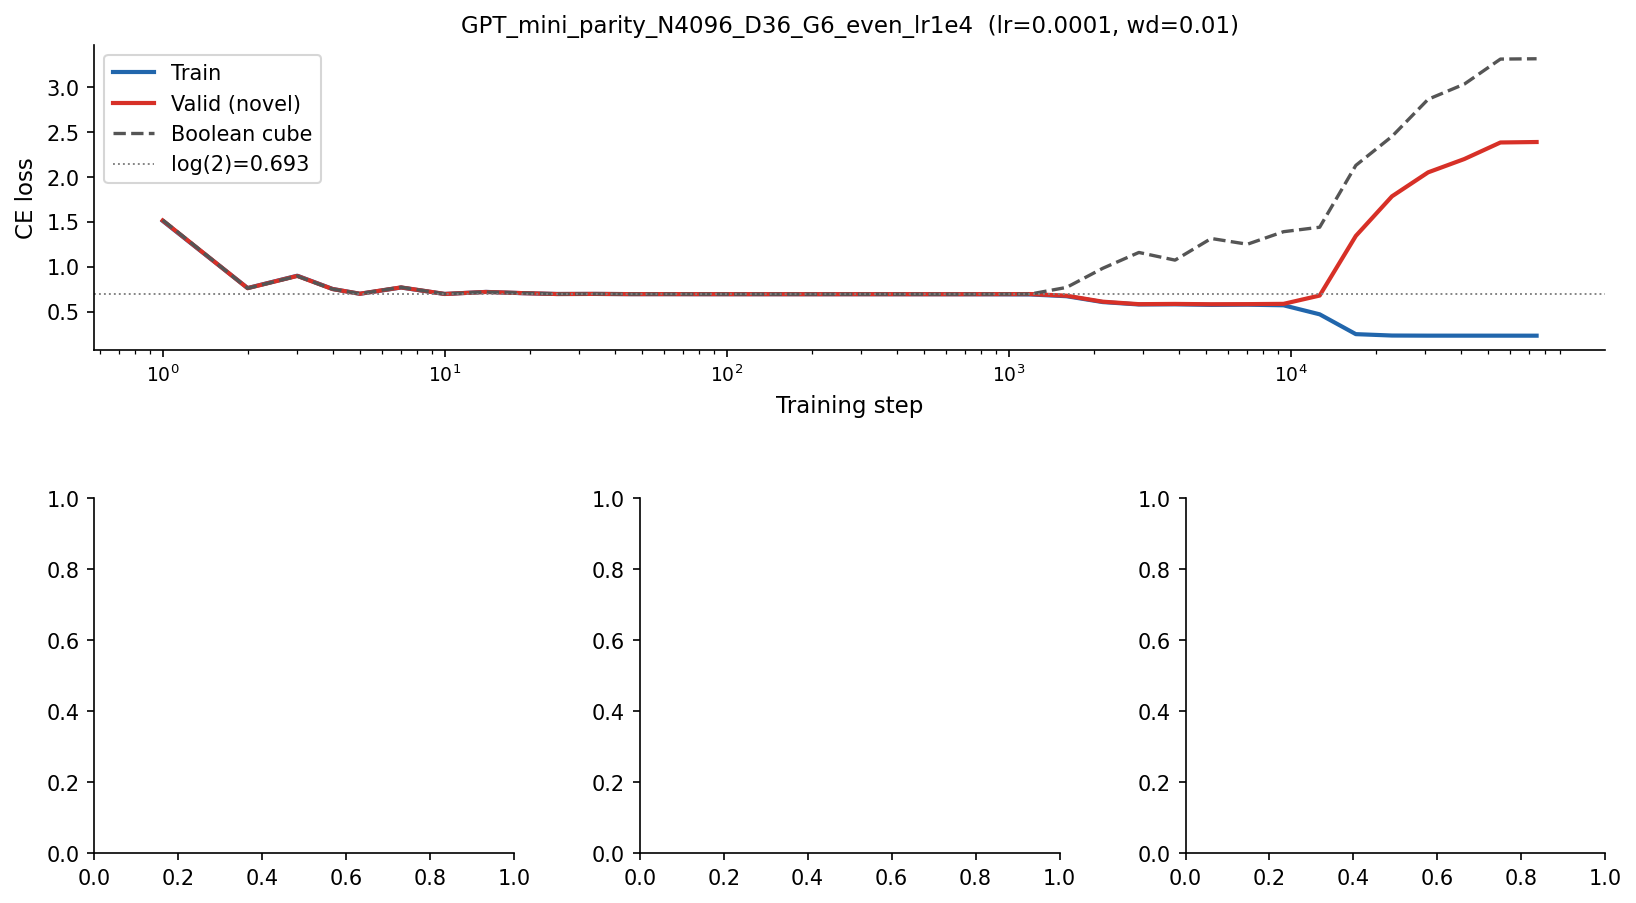

In [76]:
import json

exp_name = EXP_NAMES[0]   # ← change me
exp_dir  = os.path.join(SAVEROOT, exp_name)

d       = load_ce_data(exp_dir, n_eval=N_EVAL)
epochs  = d['epochs']
splits  = ['train', 'valid_novel', 'boolean_cube']
loss    = {s: d[f'loss_{s}']     for s in splits}
pos_loss= {s: d[f'pos_loss_{s}'] for s in splits}   # (C, 36)
n_pos   = pos_loss['train'].shape[1]

args_dict = json.loads(str(d['args_json']))
exp_tag   = args_dict.get('exp_name', os.path.basename(exp_dir))
lr        = args_dict.get('lr',            '?')
wd        = args_dict.get('weight_decay',  '?')

# ── figure layout ────────────────────────────────────────────────────────────
figsize = (13, 7)    # ← tweak
fig = plt.figure(figsize=figsize, dpi=150)
gs  = fig.add_gridspec(2, 3, height_ratios=[1.2, 1.4], hspace=0.45, wspace=0.30)

# ── top: CE loss curves ───────────────────────────────────────────────────────
ax_loss = fig.add_subplot(gs[0, :])
for s in splits:
    sty = SPLIT_STYLES[s]
    ax_loss.plot(epochs, loss[s], **sty)

ax_loss.axhline(np.log(2), color='gray', lw=0.9, ls=':', label=f'log(2)={np.log(2):.3f}')
ax_loss.set_ylabel('CE loss', fontsize=11)
ax_loss.set_title(f'{exp_tag}  (lr={lr}, wd={wd})', fontsize=11)
ax_loss.legend(loc='upper left', fontsize=10)
make_step_axis(ax_loss, epochs)

# ── bottom: per-position heatmaps ────────────────────────────────────────────
vmax = max(np.nanpercentile(pos_loss[s], 97) for s in splits)

hax = [fig.add_subplot(gs[1, c]) for c in range(3)]
for col, s in enumerate(splits):
    ax  = hax[col]
    mat = pos_loss[s].T   # (36, C)
    im  = ax.imshow(mat, aspect='auto', origin='lower',
                    cmap=HMAP_CMAPS[s],
                    norm=Normalize(vmin=0, vmax=vmax),
                    interpolation='nearest')
    group_boundary_lines(ax, GROUP_SIZE, n_pos, orientation='horizontal')
    heatmap_step_ticks(ax, epochs)
    ax.set_ylabel('Bit position' if col == 0 else '', fontsize=10)
    ax.set_title(HMAP_TITLES[s], fontsize=11)
    plt.colorbar(im, ax=ax, shrink=0.85, label='CE')

fig.suptitle('GPT CE analysis', fontsize=12, y=1.01)
plt.tight_layout()
plt.show()